# Explainable AI Framework for Identity Fraud Detection at Bank Account Opening
## Notebook 1 - Data Characterisation and Preprocessing

**Sydney Ndabai (P2929107)** · CSIP5402 · Supervisor:  Ahmad Lawal · De Montfort University

Characterises the BAF dataset, applies preprocessing, and produces the partitioned data used by Notebooks 2 and 3.

## 0. Setup

Imports libraries and fixes a global random seed so all results are reproducible. Library versions are printed for the reproducibility appendix.

In [1]:
import numpy as np
import pandas as pd
import random
import os
import warnings

import matplotlib.pyplot as plt
import sklearn

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

for lib in [np, pd, sklearn]:
    print(f"{lib.__name__:14s} {lib.__version__}")
print(f"{'SEED':14s} {SEED}")

numpy          2.0.2
pandas         2.3.3
sklearn        1.6.1
SEED           42


## 1. Load the Data

Reads the Base and Variant IV datasets and confirms both share the same schema. Base is used for model development; Variant IV is reserved for a controlled cross-variant robustness evaluation in Notebook 3.

In [2]:
BASE_PATH = "/kaggle/input/datasets/sydneyndabai/dataset-fyp/Base.csv"
VARIANT_PATH = "/kaggle/input/datasets/sydneyndabai/dataset-fyp/Variant IV.csv"

df_base = pd.read_csv(BASE_PATH)
df_variant = pd.read_csv(VARIANT_PATH)

print(f"Base shape:       {df_base.shape}")
print(f"Variant IV shape: {df_variant.shape}")
print(f"Schemas identical: {list(df_base.columns) == list(df_variant.columns)}")

Base shape:       (1000000, 32)
Variant IV shape: (1000000, 32)
Schemas identical: True


## 2. Exploratory Data Analysis

### 2.1 Structure and Data Types

Prints the schema: column names, non-null counts, and data types.

In [3]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                            Non-Null Count    Dtype  
---  ------                            --------------    -----  
 0   fraud_bool                        1000000 non-null  int64  
 1   income                            1000000 non-null  float64
 2   name_email_similarity             1000000 non-null  float64
 3   prev_address_months_count         1000000 non-null  int64  
 4   current_address_months_count      1000000 non-null  int64  
 5   customer_age                      1000000 non-null  int64  
 6   days_since_request                1000000 non-null  float64
 7   intended_balcon_amount            1000000 non-null  float64
 8   payment_type                      1000000 non-null  object 
 9   zip_count_4w                      1000000 non-null  int64  
 10  velocity_6h                       1000000 non-null  float64
 11  velocity_24h                      1000

### 2.2 Class Distribution

Quantifies fraud prevalence and the resulting imbalance ratio. This figure determines the choice of evaluation metrics throughout the study.

In [4]:
fraud_rate = df_base["fraud_bool"].mean()
n_fraud = int(df_base["fraud_bool"].sum())

print(f"Total applications:  {len(df_base):,}")
print(f"Fraudulent:          {n_fraud:,} ({fraud_rate*100:.2f}%)")
print(f"Legitimate:          {len(df_base)-n_fraud:,} ({(1-fraud_rate)*100:.2f}%)")
print(f"Imbalance ratio:     1 fraud per {(1-fraud_rate)/fraud_rate:.1f} legitimate applications")

Total applications:  1,000,000
Fraudulent:          11,029 (1.10%)
Legitimate:          988,971 (98.90%)
Imbalance ratio:     1 fraud per 89.7 legitimate applications


### 2.3 Sentinel (Missing-Value) Audit

`info()` reports no missing values, but the BAF dataset uses sentinel values to represent missing information in specific features. For the documented sentinel features, this audit counts negative-valued records to quantify the extent of encoded missingness before preprocessing.

In [5]:
sentinel_cols = [
    "prev_address_months_count",
    "current_address_months_count",
    "bank_months_count",
    "session_length_in_minutes",
    "device_distinct_emails_8w",
    "intended_balcon_amount",
]

audit = [{"feature": c,
          "n_negative": int((df_base[c] < 0).sum()),
          "pct_negative": round((df_base[c] < 0).mean() * 100, 2)}
         for c in sentinel_cols]

sentinel_audit = pd.DataFrame(audit).sort_values("pct_negative", ascending=False).reset_index(drop=True)
sentinel_audit

,feature,n_negative,pct_negative
0,intended_balcon_amount,742523,74.25
1,prev_address_months_count,712920,71.29
2,bank_months_count,253635,25.36
3,current_address_months_count,4254,0.43
4,session_length_in_minutes,2015,0.20
5,device_distinct_emails_8w,359,0.04


### 2.4 Sentinel Verification

Not every negative value means "missing". The first cell scans *all* numeric features for negatives; the second counts how many *distinct* negative values each contains. A sentinel is a single repeated code; a genuine measurement takes a range of values.

In [6]:
numeric_cols = df_base.select_dtypes(include=["int64", "float64"]).columns

neg_scan = [{"feature": c,
             "n_negative": int((df_base[c] < 0).sum()),
             "pct": round((df_base[c] < 0).mean() * 100, 2)}
            for c in numeric_cols if (df_base[c] < 0).any()]

pd.DataFrame(neg_scan).sort_values("pct", ascending=False).reset_index(drop=True)

,feature,n_negative,pct
0,intended_balcon_amount,742523,74.25
1,prev_address_months_count,712920,71.29
2,bank_months_count,253635,25.36
3,credit_risk_score,14445,1.44
4,current_address_months_count,4254,0.43
5,session_length_in_minutes,2015,0.20
6,device_distinct_emails_8w,359,0.04
7,velocity_6h,44,0.00


In [7]:
card = []
for c in [r["feature"] for r in neg_scan]:
    neg = df_base.loc[df_base[c] < 0, c]
    card.append({"feature": c,
                 "distinct_negatives": int(neg.nunique()),
                 "min": round(float(neg.min()), 3),
                 "max": round(float(neg.max()), 3)})

pd.DataFrame(card).sort_values("distinct_negatives").reset_index(drop=True)

,feature,distinct_negatives,min,max
0,prev_address_months_count,1,-1.000,-1.00
1,current_address_months_count,1,-1.000,-1.00
2,session_length_in_minutes,1,-1.000,-1.00
3,bank_months_count,1,-1.000,-1.00
4,device_distinct_emails_8w,1,-1.000,-1.00
5,velocity_6h,44,-170.603,-1.89
6,credit_risk_score,164,-170.000,-1.00
7,intended_balcon_amount,737834,-15.531,-0.00


Five features take a single negative value (−1) and are treated as missing. `credit_risk_score` (164 distinct negatives) and `velocity_6h` (44) take continuous ranges and are genuine measurements, so are left untransformed. `intended_balcon_amount` is treated as missing on domain grounds, a transfer amount cannot be negative and per the BAF datasheet.

### 2.5 Duplicate Records

Checks for exact duplicates, and specifically for records shared between the training and test months, which would constitute leakage.

In [8]:
feat_only = [c for c in df_base.columns if c not in ["fraud_bool", "month"]]

print(f"Base, exact duplicate rows:              {df_base.duplicated().sum():,}")
print(f"Variant IV, exact duplicate rows:        {df_variant.duplicated().sum():,}")
print(f"Base, duplicate feature-vectors:         {df_base.duplicated(subset=feat_only).sum():,}")

early = df_base.loc[df_base["month"] <= 5, feat_only].drop_duplicates()
late = df_base.loc[df_base["month"] == 7, feat_only].drop_duplicates()
overlap = pd.merge(early, late, how="inner")
print(f"Feature-vectors shared between train months (0-5) and test month (7): {len(overlap):,}")

Base, exact duplicate rows:              0
Variant IV, exact duplicate rows:        0
Base, duplicate feature-vectors:         0
Feature-vectors shared between train months (0-5) and test month (7): 0


### 2.6 Is Missingness Informative?

Compares fraud prevalence between records where each sentinel feature is missing and where it is present, using only the development training window (months 0–5). Restricting this target-based descriptive analysis to the training period ensures that validation month 6 and held-out test month 7 do not influence the interpretation of missingness. Missingness indicators are created for all six documented sentinel features irrespective of these descriptive associations.

In [9]:
# Restrict target-based descriptive analysis to the training window only.
# Months 6 and 7 remain untouched by this analysis.

eda_train = df_base.loc[df_base["month"].between(0, 5)].copy()

overall = eda_train["fraud_bool"].mean()
rows = []

for c in sentinel_cols:
    m = eda_train[c] < 0

    fm = eda_train.loc[m, "fraud_bool"].mean()
    fp = eda_train.loc[~m, "fraud_bool"].mean()

    rows.append({
        "feature": c,
        "fraud_when_missing": round(fm, 4),
        "fraud_when_present": round(fp, 4),
        "ratio": round(fm / fp, 2)
    })

missingness_signal = (
    pd.DataFrame(rows)
    .sort_values("ratio", ascending=False)
    .reset_index(drop=True)
)

print(f"Training-window applications (months 0-5): {len(eda_train):,}")
print(f"Training-window fraud rate: {overall:.4f}\n")

missingness_signal

Training-window applications (months 0-5): 794,989
Training-window fraud rate: 0.0103



,feature,fraud_when_missing,fraud_when_present,ratio
0,prev_address_months_count,0.0132,0.0028,4.73
1,intended_balcon_amount,0.0122,0.0047,2.58
2,bank_months_count,0.0154,0.0085,1.80
3,device_distinct_emails_8w,0.0097,0.0103,0.95
4,session_length_in_minutes,0.0086,0.0103,0.84
5,current_address_months_count,0.0030,0.0103,0.29


Missingness showed differing associations with fraud prevalence within the months 0–5 training window. The strongest positive association was observed for prev_address_months_count, for which fraud prevalence was approximately 4.73 times higher among records with a missing value than among those with a recorded value. Positive associations were also observed for intended_balcon_amount (2.58×) and bank_months_count (1.80×). In contrast, device_distinct_emails_8w, session_length_in_minutes, and current_address_months_count did not show higher fraud prevalence when missing. These results represent descriptive associations rather than causal relationships. Missingness indicators were retained for all six documented sentinel features, with their predictive contribution subsequently assessed using SHAP.

### 2.7 Temporal Structure

Reports application volume and fraud rate per month. Whether these are stable determines whether a random split is valid.

In [10]:
monthly = df_base.groupby("month").agg(
    n_applications=("fraud_bool", "size"),
    n_fraud=("fraud_bool", "sum"),
    fraud_rate=("fraud_bool", "mean"),
)
monthly["fraud_rate"] = monthly["fraud_rate"].round(4)
monthly

,n_applications,n_fraud,fraud_rate
month,,,
0,132440,1500,0.0113
1,127620,1198,0.0094
2,136979,1198,0.0087
3,150936,1392,0.0092
4,127691,1452,0.0114
5,119323,1411,0.0118
6,108168,1450,0.0134
7,96843,1428,0.0147


### 2.8 Visualising Temporal Drift

Plots volume (bars) against fraud rate (line) on twin axes, with the train/validation/test boundaries shaded.

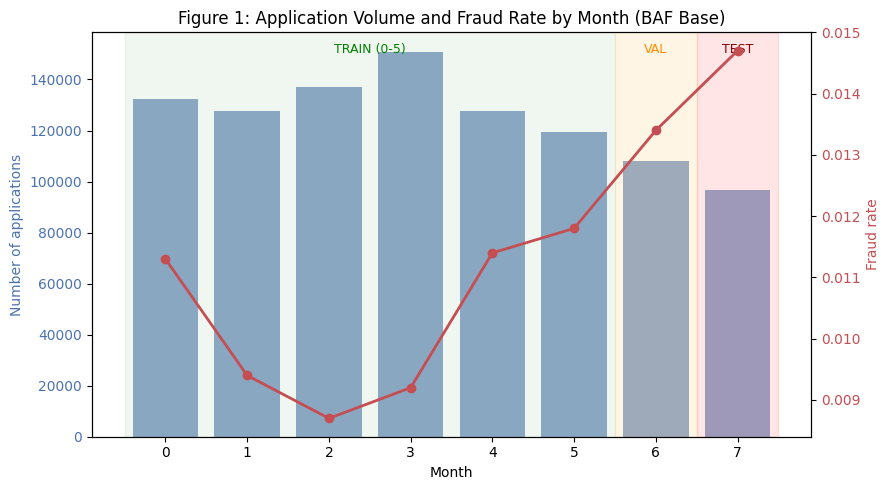

In [11]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.bar(monthly.index, monthly["n_applications"], color="#4C72B0", alpha=0.6)
ax1.set_xlabel("Month")
ax1.set_ylabel("Number of applications", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["fraud_rate"], color="#C44E52", marker="o", linewidth=2)
ax2.set_ylabel("Fraud rate", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")

ax1.axvspan(-0.5, 5.5, alpha=0.06, color="green")
ax1.axvspan(5.5, 6.5, alpha=0.10, color="orange")
ax1.axvspan(6.5, 7.5, alpha=0.10, color="red")
ax1.text(2.5, ax1.get_ylim()[1]*0.95, "TRAIN (0-5)", ha="center", fontsize=9, color="green")
ax1.text(6.0, ax1.get_ylim()[1]*0.95, "VAL", ha="center", fontsize=9, color="darkorange")
ax1.text(7.0, ax1.get_ylim()[1]*0.95, "TEST", ha="center", fontsize=9, color="darkred")

plt.title("Figure 1: Application Volume and Fraud Rate by Month (BAF Base)")
fig.tight_layout()
plt.savefig("fig1_temporal_drift.png", dpi=200, bbox_inches="tight")
plt.show()

Fraud rises from 0.87% (month 2) to 1.47% (month 7) while volume falls. The process is non-stationary, so a random split would place later records in training and evaluate on earlier ones incorporating information unavailable at prediction time. This justifies the temporal split in Section 3.2.

## 3. Preprocessing

### 3.1 Missing-Indicator Features

Creates a binary flag for each sentinel feature, preserving missingness as a signal rather than imputing it. Applied identically to Base and Variant IV so the robustness comparison is not confounded.

In [12]:
def add_missing_indicators(df, cols):
    df = df.copy()
    for col in cols:
        df[f"{col}_missing"] = (df[col] < 0).astype(int)
    return df

df_base = add_missing_indicators(df_base, sentinel_cols)
df_variant = add_missing_indicators(df_variant, sentinel_cols)

new_flags = [f"{c}_missing" for c in sentinel_cols]
print(f"Indicator features added: {len(new_flags)}")
print(f"Base shape:       {df_base.shape}")
print(f"Variant IV shape: {df_variant.shape}")
df_base[new_flags].head()

Indicator features added: 6
Base shape:       (1000000, 38)
Variant IV shape: (1000000, 38)


,prev_address_months_count_missing,current_address_months_count_missing,bank_months_count_missing,session_length_in_minutes_missing,device_distinct_emails_8w_missing,intended_balcon_amount_missing
0,1,0,0,0,0,0
1,1,0,0,0,0,1
2,0,0,0,0,0,1
3,0,0,0,0,0,1
4,1,0,0,0,0,0


### 3.2 Temporal Split

Partitions by month: **train 0–5**, **validation 6**, **test 7**.

Training uses only periods preceding those on which it is assessed, preventing look-ahead leakage. Hyperparameter selection is performed using walk-forward validation confined to the training window (months 0–5). Month 6 is held out exclusively for validation and decision-threshold calibration at the target 5% false-positive rate, while month 7 remains untouched until the final evaluation.

Cost of this configuration: a single test month contains 1,428 fraud cases rather than 2,878 across two months, so confidence intervals are roughly 1.4× wider and significance tests have less power. This is reported rather than concealed.

In [13]:
train = df_base[df_base["month"] <= 5].copy()
val   = df_base[df_base["month"] == 6].copy()
test  = df_base[df_base["month"] == 7].copy()

summary = pd.DataFrame([
    {"Partition": "Train (months 0-5)", "Rows": len(train), "Share": f"{len(train)/len(df_base)*100:.1f}%",
     "Fraud rate": round(train["fraud_bool"].mean(), 4), "Fraud cases": int(train["fraud_bool"].sum())},
    {"Partition": "Validation (month 6)", "Rows": len(val), "Share": f"{len(val)/len(df_base)*100:.1f}%",
     "Fraud rate": round(val["fraud_bool"].mean(), 4), "Fraud cases": int(val["fraud_bool"].sum())},
    {"Partition": "Test (month 7)", "Rows": len(test), "Share": f"{len(test)/len(df_base)*100:.1f}%",
     "Fraud rate": round(test["fraud_bool"].mean(), 4), "Fraud cases": int(test["fraud_bool"].sum())},
])

print(summary.to_string(index=False))
print(f"\nIntegrity check: {len(train) + len(val) + len(test):,} == {len(df_base):,}  "
      f"{len(train) + len(val) + len(test) == len(df_base)}")

           Partition   Rows Share  Fraud rate  Fraud cases
  Train (months 0-5) 794989 79.5%      0.0103         8151
Validation (month 6) 108168 10.8%      0.0134         1450
      Test (month 7)  96843  9.7%      0.0147         1428

Integrity check: 1,000,000 == 1,000,000  True


Fraud prevalence rises across the three partitions (1.03% → 1.34% → 1.47%), so the model trains under easier conditions than it is tested on. Validation and test are adjacent and similar in prevalence, so a threshold calibrated on month 6 should transfer to month 7 with limited drift; the realised test FPR is reported in Notebook 3.

### 3.3 Feature Definitions

Defines the predictor set once, here, so every later notebook uses an identical feature space. Three columns are excluded: `fraud_bool` (the target), `month` (a partition artefact, retaining it would let the model condition on period rather than applicant), and `device_fraud_count`, verified below as degenerate.

In [14]:
TARGET = "fraud_bool"
DROP_COLS = ["fraud_bool", "month", "device_fraud_count"]
categorical_cols = ["payment_type", "employment_status", "housing_status", "source", "device_os"]

feature_cols = [c for c in train.columns if c not in DROP_COLS]
numeric_cols = [c for c in feature_cols if c not in categorical_cols]

print(f"device_fraud_count distinct values in training data: {train['device_fraud_count'].nunique()}")
print(f"device_fraud_count standard deviation:               {train['device_fraud_count'].std():.6f}")
print(f"  -> degenerate; carries no discriminative information\n")

print(f"Predictors: {len(feature_cols)}  ({len(categorical_cols)} categorical, {len(numeric_cols)} numeric)")
print(f"Excluded:   {DROP_COLS}")

device_fraud_count distinct values in training data: 1
device_fraud_count standard deviation:               0.000000
  -> degenerate; carries no discriminative information

Predictors: 35  (5 categorical, 30 numeric)
Excluded:   ['fraud_bool', 'month', 'device_fraud_count']


## 4. Save Processed Data

Writes the partitions, the processed Variant IV set, and the feature configuration to Parquet and joblib. Notebooks 2 and 3 load these directly, so preprocessing runs exactly once and cannot diverge between notebooks.

In [15]:
import joblib

train.to_parquet("train.parquet", index=False)
val.to_parquet("val.parquet", index=False)
test.to_parquet("test.parquet", index=False)
df_variant.to_parquet("variant_iv.parquet", index=False)

feature_config = {
    "TARGET": TARGET,
    "DROP_COLS": DROP_COLS,
    "feature_cols": feature_cols,
    "categorical_cols": categorical_cols,
    "numeric_cols": numeric_cols,
    "sentinel_cols": sentinel_cols,
    "SEED": SEED,
    "split": {"train_months": [0, 1, 2, 3, 4, 5], "val_month": 6, "test_month": 7},
}
joblib.dump(feature_config, "feature_config.pkl")

for f in ["train.parquet", "val.parquet", "test.parquet", "variant_iv.parquet", "feature_config.pkl"]:
    print(f"{f:24s} {os.path.getsize(f)/1e6:7.1f} MB")

train.parquet               56.0 MB
val.parquet                  8.9 MB
test.parquet                 8.0 MB
variant_iv.parquet          70.0 MB
feature_config.pkl           0.0 MB


## 5. Summary

| Finding | Value | Consequence |
|---|---|---|
| Fraud prevalence | 1.10% | Rules out accuracy as a metric |
| Sentinel-encoded missingness | 6 features, two above 70% | Missing-indicator features created |
| Training-window missingness association | up to 4.73× fraud prevalence | Missingness retained as explicit indicators; model contribution assessed subsequently using SHAP |
| Temporal drift | 0.87% → 1.47% | Temporal split, not random |

**Outputs:** `train.parquet` (794,989), `val.parquet` (108,168), `test.parquet` (96,843), `variant_iv.parquet`, `feature_config.pkl`.